# 01 — Leading-Indicator Analysis for Alternative-Data Credit Early-Warning

**Proof-of-concept for the governance-embedded opportunity-screening framework (DSR artifact, Demonstration step).**

Research question tested here (RQ1, opportunity axis): *Do weak activity signals lead confirmed credit-event indicators in time?*

- **Weak signals (candidate proxies):** business opening rate, net-entry rate, opening-to-closure ratio.
- **Confirmed credit-event indicators (lagging targets):** business closure rate, exit rate.
- **Data:** Statistics Canada, Table 33-10-0270-01, *Experimental estimates for business openings and closures* (monthly, seasonally adjusted, national business-sector aggregate, 2015-01 to 2026-05). Public, open licence.
- **Methods:** stationarity (ADF), cross-correlation function (CCF), Granger causality, and a proxy-screening scorecard operationalising the framework's opportunity-layer criteria.

Note: aggregate series only — no individual firm data — so no privacy exposure. This demonstrates the *screening logic*, not a deployed predictive model.

In [1]:
# Imports and global configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

# Paths (relative to notebooks/ working directory)
DATA = Path('../data')
FIG  = Path('../results/figures')
TAB  = Path('../results/tables')
for p in (FIG, TAB):
    p.mkdir(parents=True, exist_ok=True)

# Greyscale, publication-style figure settings
sns.set_theme(style='whitegrid', context='paper')
sns.set_palette('Greys')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'axes.edgecolor': '0.2',
    'axes.grid': True,
    'grid.color': '0.85',
    'image.cmap': 'Greys',
})
GREY_DARK, GREY_MID, GREY_LIGHT = '0.15', '0.45', '0.70'

def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi, no caption."""
    fig.savefig(FIG / f'{name}.png', dpi=600, bbox_inches='tight')
    fig.savefig(FIG / f'{name}.pdf', dpi=600, bbox_inches='tight')
    print(f'saved: {name}.png / {name}.pdf')

## 1. Load and construct signal / target series

In [2]:
# Load the clean national monthly panel
df = pd.read_csv(DATA / 'canada_business_dynamics_national_monthly.csv',
                 index_col=0, parse_dates=True).sort_index()

# Rates are normalised by the active-business stock (per 1,000 active businesses)
active = df['Active businesses']
rates = pd.DataFrame(index=df.index)
rates['opening_rate']   = df['Opening businesses'] / active * 1000
rates['closure_rate']   = df['Closing businesses'] / active * 1000
rates['entrant_rate']   = df['Entrants']           / active * 1000
rates['exit_rate']      = df['Exits']              / active * 1000

# Composite weak signals
rates['net_entry_rate']       = rates['entrant_rate'] - rates['exit_rate']
rates['open_close_ratio']     = df['Opening businesses'] / df['Closing businesses']

# Restrict to complete observations
rates = rates.dropna()
print(rates.shape)
rates.describe().round(3)

(131, 6)


,opening_rate,closure_rate,entrant_rate,exit_rate,net_entry_rate,open_close_ratio
count,131.000,131.000,131.000,131.000,131.000,131.000
mean,47.944,47.241,17.322,16.591,0.732,1.034
std,5.162,9.811,2.359,2.398,2.678,0.145
min,37.706,35.538,10.367,11.724,-16.303,0.338
25%,45.930,44.369,16.549,15.460,-0.270,0.990
50%,47.270,46.127,17.309,16.228,1.160,1.017
75%,48.290,47.351,18.197,17.108,2.139,1.064
max,78.158,135.127,33.898,30.647,5.650,1.791


## 2. Descriptive time-series plot of signals and targets

saved: fig1_series_overview.png / fig1_series_overview.pdf


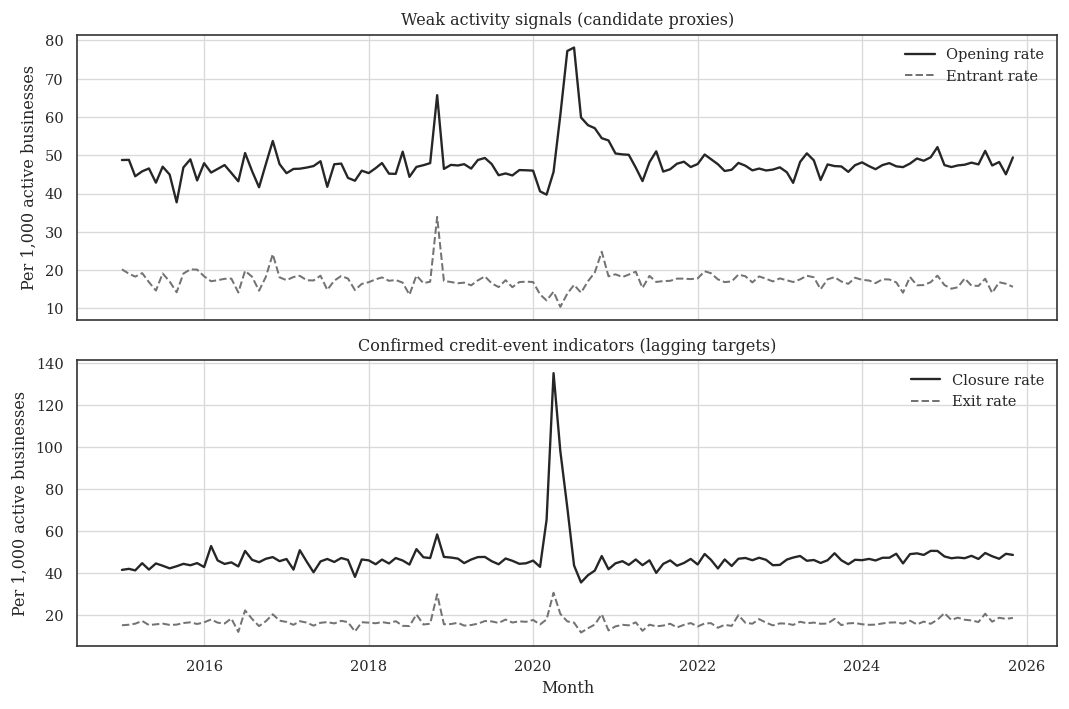

In [3]:
# Plot candidate weak signals against confirmed credit-event indicators
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(rates.index, rates['opening_rate'], color=GREY_DARK, lw=1.4, label='Opening rate')
axes[0].plot(rates.index, rates['entrant_rate'], color=GREY_MID, lw=1.2, ls='--', label='Entrant rate')
axes[0].set_ylabel('Per 1,000 active businesses')
axes[0].set_title('Weak activity signals (candidate proxies)')
axes[0].legend(frameon=False)

axes[1].plot(rates.index, rates['closure_rate'], color=GREY_DARK, lw=1.4, label='Closure rate')
axes[1].plot(rates.index, rates['exit_rate'], color=GREY_MID, lw=1.2, ls='--', label='Exit rate')
axes[1].set_ylabel('Per 1,000 active businesses')
axes[1].set_title('Confirmed credit-event indicators (lagging targets)')
axes[1].set_xlabel('Month')
axes[1].legend(frameon=False)

fig.tight_layout()
save_fig(fig, 'fig1_series_overview')
plt.show()

## 3. Stationarity testing (ADF)

Cross-correlation and Granger causality assume stationary series. We test levels, difference where needed, and record results.

In [4]:
def adf_report(series, name):
    """Run ADF on a series; return dict with statistic, p-value, and decision."""
    s = series.dropna()
    stat, p, *_ = adfuller(s, autolag='AIC')
    return {'series': name, 'adf_stat': round(stat, 3), 'p_value': round(p, 4),
            'stationary_5pct': p < 0.05, 'n': len(s)}

signals = ['opening_rate', 'entrant_rate', 'net_entry_rate', 'open_close_ratio']
targets = ['closure_rate', 'exit_rate']

adf_rows = []
for col in signals + targets:
    adf_rows.append(adf_report(rates[col], col + ' (level)'))
    adf_rows.append(adf_report(rates[col].diff(), col + ' (diff)'))

adf_df = pd.DataFrame(adf_rows)
adf_df.to_csv(TAB / 'table1_adf_stationarity.csv', index=False)
print('saved: table1_adf_stationarity.csv')
adf_df

saved: table1_adf_stationarity.csv


,series,adf_stat,p_value,stationary_5pct,n
0,opening_rate (level),-5.447,0.0,True,131
1,opening_rate (diff),-8.005,0.0,True,130
2,entrant_rate (level),-9.449,0.0,True,131
3,entrant_rate (diff),-7.352,0.0,True,130
4,net_entry_rate (level),-5.060,0.0,True,131
5,net_entry_rate (diff),-13.453,0.0,True,130
6,open_close_ratio (level),-6.359,0.0,True,131
7,open_close_ratio (diff),-6.543,0.0,True,130
8,closure_rate (level),-6.473,0.0,True,131
9,closure_rate (diff),-8.774,0.0,True,130


In [5]:
# Use first differences for all series to ensure stationarity in the lead-lag analysis
d = rates[signals + targets].diff().dropna()
print('differenced sample:', d.shape)

differenced sample: (130, 6)


## 4. Cross-correlation function (CCF): does the signal lead the target?

We compute the correlation between a signal at time *t* and a target at time *t+k*. A peak at positive *k* means the signal **leads** the target by *k* months.

In [6]:
def lead_lag_ccf(signal, target, max_lag=12):
    """Correlate signal_t with target_{t+k} for k in [-max_lag, max_lag].
    Positive k => signal leads target."""
    x = signal.values
    y = target.values
    lags = range(-max_lag, max_lag + 1)
    out = []
    for k in lags:
        if k >= 0:
            a, b = x[:len(x) - k], y[k:]
        else:
            a, b = x[-k:], y[:len(y) + k]
        if len(a) > 3:
            r = np.corrcoef(a, b)[0, 1]
        else:
            r = np.nan
        out.append((k, r))
    return pd.DataFrame(out, columns=['lag', 'corr'])

MAX_LAG = 12
ccf_results = {}
for sig in signals:
    for tgt in targets:
        ccf_results[(sig, tgt)] = lead_lag_ccf(d[sig], d[tgt], MAX_LAG)

# Summary: peak (absolute) correlation and the lag at which it occurs
peak_rows = []
for (sig, tgt), tab in ccf_results.items():
    valid = tab.dropna()
    idx = valid['corr'].abs().idxmax()
    peak_rows.append({'signal': sig, 'target': tgt,
                      'peak_lag_months': int(valid.loc[idx, 'lag']),
                      'peak_corr': round(valid.loc[idx, 'corr'], 3)})
peak_df = pd.DataFrame(peak_rows)
peak_df.to_csv(TAB / 'table2_ccf_peaks.csv', index=False)
print('saved: table2_ccf_peaks.csv')
peak_df

saved: table2_ccf_peaks.csv


,signal,target,peak_lag_months,peak_corr
0,opening_rate,closure_rate,-2,0.382
1,opening_rate,exit_rate,0,0.394
2,entrant_rate,closure_rate,0,0.266
3,entrant_rate,exit_rate,0,0.760
4,net_entry_rate,closure_rate,0,-0.602
5,net_entry_rate,exit_rate,0,-0.423
6,open_close_ratio,closure_rate,0,-0.630
7,open_close_ratio,exit_rate,4,0.272


saved: fig2_ccf_leadlag.png / fig2_ccf_leadlag.pdf


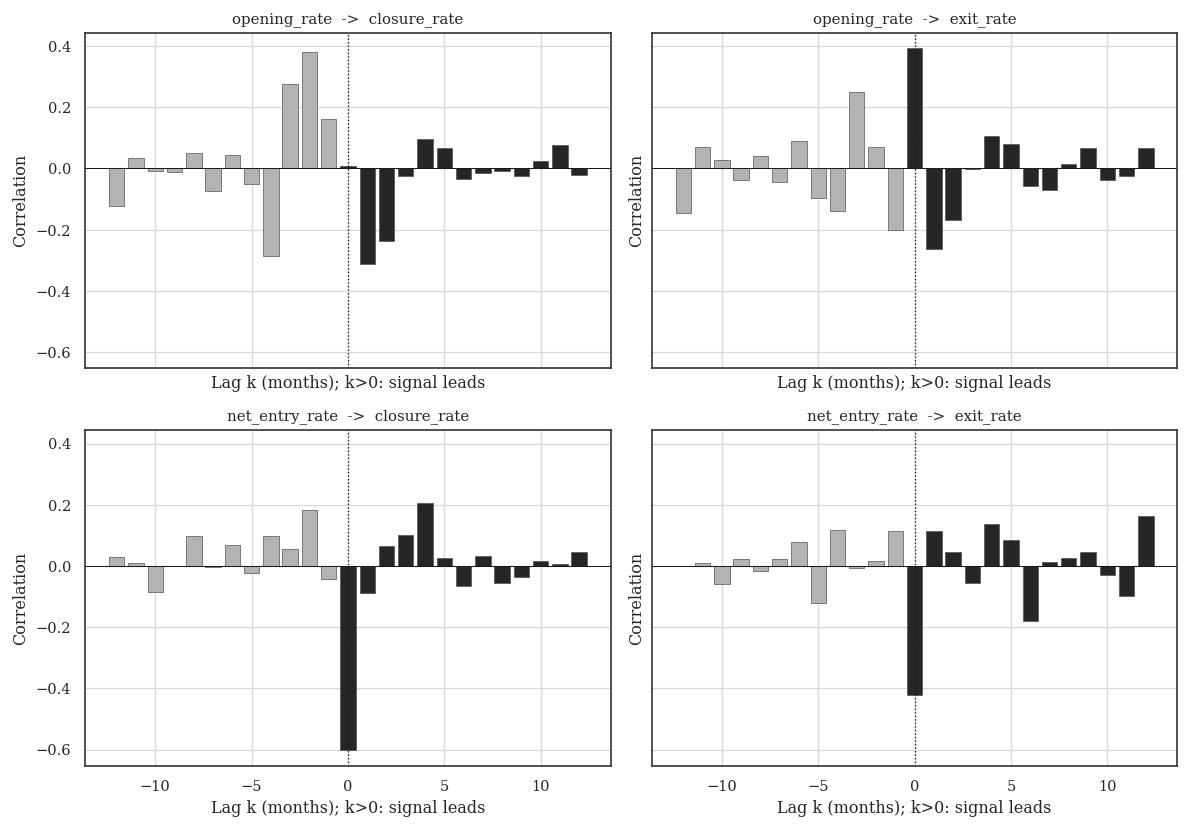

In [7]:
# CCF plot for the strongest leading pair (opening/net-entry signals vs closure/exit)
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
pairs = [('opening_rate', 'closure_rate'), ('opening_rate', 'exit_rate'),
         ('net_entry_rate', 'closure_rate'), ('net_entry_rate', 'exit_rate')]

for ax, (sig, tgt) in zip(axes.ravel(), pairs):
    tab = ccf_results[(sig, tgt)]
    colors = [GREY_DARK if l >= 0 else GREY_LIGHT for l in tab['lag']]
    ax.bar(tab['lag'], tab['corr'], color=colors, width=0.8, edgecolor='0.3', linewidth=0.4)
    ax.axvline(0, color='0.1', lw=0.8, ls=':')
    ax.axhline(0, color='0.1', lw=0.6)
    ax.set_title(f'{sig}  ->  {tgt}', fontsize=9)
    ax.set_xlabel('Lag k (months); k>0: signal leads')
    ax.set_ylabel('Correlation')

fig.tight_layout()
save_fig(fig, 'fig2_ccf_leadlag')
plt.show()

## 5. Granger causality: does the signal help predict the target?

In [8]:
def granger_min_p(signal, target, max_lag=6):
    """Test whether `signal` Granger-causes `target`.
    Returns the minimum p-value across lags 1..max_lag and the best lag."""
    data = pd.concat([target, signal], axis=1).dropna()
    data.columns = ['target', 'signal']
    import io, contextlib
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            res = grangercausalitytests(data[['target', 'signal']], maxlag=max_lag)
        ps = {lag: res[lag][0]['ssr_ftest'][1] for lag in res}
        best = min(ps, key=ps.get)
        return best, ps[best]
    except Exception as e:
        return np.nan, np.nan

g_rows = []
for sig in signals:
    for tgt in targets:
        best_lag, p = granger_min_p(d[sig], d[tgt], max_lag=6)
        g_rows.append({'signal': sig, 'target': tgt,
                       'best_lag': best_lag,
                       'min_p_value': round(p, 4) if p == p else np.nan,
                       'significant_5pct': (p < 0.05) if p == p else False})
granger_df = pd.DataFrame(g_rows)
granger_df.to_csv(TAB / 'table3_granger.csv', index=False)
print('saved: table3_granger.csv')
granger_df

saved: table3_granger.csv


,signal,target,best_lag,min_p_value,significant_5pct
0,opening_rate,closure_rate,2,0.0000,True
1,opening_rate,exit_rate,3,0.0000,True
2,entrant_rate,closure_rate,2,0.0065,True
3,entrant_rate,exit_rate,6,0.0381,True
4,net_entry_rate,closure_rate,6,0.1318,False
5,net_entry_rate,exit_rate,6,0.0381,True
6,open_close_ratio,closure_rate,3,0.0000,True
7,open_close_ratio,exit_rate,4,0.0000,True


## 6. Proxy-screening scorecard (framework opportunity-layer, operationalised)

The framework's opportunity layer scores each candidate proxy on:
**leadingness** (does it lead, and by how much), **signal strength** (peak correlation),
**predictive value** (Granger significance), and **freshness** (update cadence — monthly here).
This turns the qualitative design principle into a reproducible judgement.

In [9]:
# Build the scorecard by combining CCF and Granger evidence for each signal
score_rows = []
for sig in signals:
    # take the target for which this signal shows the strongest leading relationship
    best = None
    for tgt in targets:
        tab = ccf_results[(sig, tgt)].dropna()
        lead = tab[tab['lag'] > 0]
        if lead.empty:
            continue
        idx = lead['corr'].abs().idxmax()
        cand = {'target': tgt, 'lead_lag': int(lead.loc[idx, 'lag']),
                'lead_corr': lead.loc[idx, 'corr']}
        if best is None or abs(cand['lead_corr']) > abs(best['lead_corr']):
            best = cand
    gp = granger_df[(granger_df['signal'] == sig) & (granger_df['target'] == best['target'])]['min_p_value'].values[0]

    leadingness  = min(best['lead_lag'] / 6.0, 1.0)          # normalise: 6+ months lead = full score
    strength     = min(abs(best['lead_corr']) / 0.5, 1.0)     # |r|>=0.5 = full score
    predictive   = 1.0 if (gp == gp and gp < 0.05) else 0.4   # Granger significant vs not
    freshness    = 1.0                                        # monthly cadence
    composite    = round(np.mean([leadingness, strength, predictive, freshness]), 3)

    score_rows.append({'proxy': sig, 'best_target': best['target'],
                       'lead_lag_months': best['lead_lag'],
                       'lead_corr': round(best['lead_corr'], 3),
                       'leadingness': round(leadingness, 2),
                       'signal_strength': round(strength, 2),
                       'predictive_value': predictive,
                       'freshness': freshness,
                       'composite_score': composite,
                       'screen_decision': 'ADOPT' if composite >= 0.6 else ('CONDITIONAL' if composite >= 0.4 else 'REJECT')})

score_df = pd.DataFrame(score_rows).sort_values('composite_score', ascending=False)
score_df.to_csv(TAB / 'table4_proxy_scorecard.csv', index=False)
print('saved: table4_proxy_scorecard.csv')
score_df

saved: table4_proxy_scorecard.csv


,proxy,best_target,lead_lag_months,lead_corr,leadingness,signal_strength,predictive_value,freshness,composite_score,screen_decision
3,open_close_ratio,exit_rate,4,0.272,0.67,0.54,1.0,1.0,0.803,ADOPT
1,entrant_rate,exit_rate,1,-0.396,0.17,0.79,1.0,1.0,0.740,ADOPT
0,opening_rate,closure_rate,1,-0.312,0.17,0.62,1.0,1.0,0.698,ADOPT
2,net_entry_rate,closure_rate,4,0.205,0.67,0.41,0.4,1.0,0.619,ADOPT


saved: fig3_scorecard_heatmap.png / fig3_scorecard_heatmap.pdf


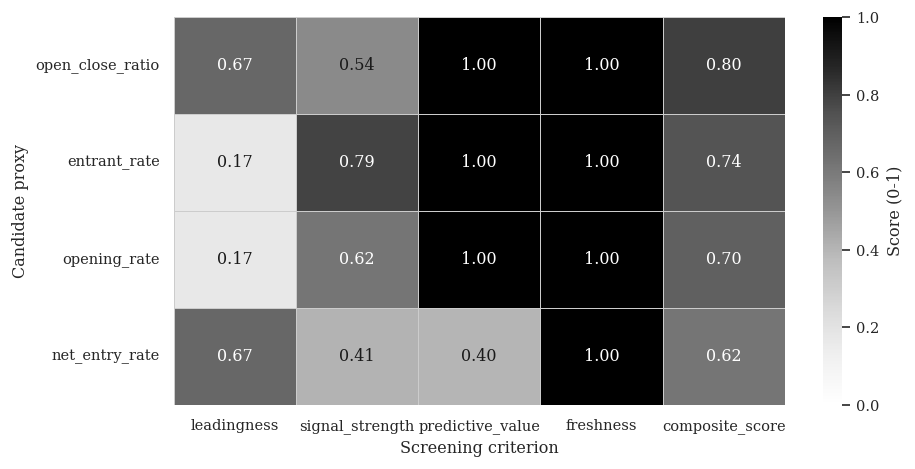

In [10]:
# Heatmap of the scorecard components (greyscale)
comp_cols = ['leadingness', 'signal_strength', 'predictive_value', 'freshness', 'composite_score']
hm = score_df.set_index('proxy')[comp_cols]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='Greys', vmin=0, vmax=1,
            linewidths=0.5, linecolor='0.8', cbar_kws={'label': 'Score (0-1)'},
            ax=ax)
# Set each annotation's colour by cell darkness so text stays legible
vals = hm.values.ravel()
for txt, v in zip(ax.texts, vals):
    txt.set_color('white' if v > 0.55 else '0.1')
ax.set_ylabel('Candidate proxy')
ax.set_xlabel('Screening criterion')
fig.tight_layout()
save_fig(fig, 'fig3_scorecard_heatmap')
plt.show()

## 7. Robustness: provincial cross-section of the leading relationship

In [11]:
# Recompute the opening -> closure lead-lag peak across provinces
prov = pd.read_csv(DATA / 'canada_business_dynamics_provincial_monthly.csv', parse_dates=['REF_DATE'])

def prov_series(g):
    w = g.pivot_table(index='REF_DATE', columns='Business dynamics measure', values='VALUE', aggfunc='first').sort_index()
    a = w['Active businesses']
    return pd.DataFrame({'opening_rate': w['Opening businesses'] / a * 1000,
                         'closure_rate': w['Closing businesses'] / a * 1000}).dropna()

rob_rows = []
for geo, g in prov.groupby('GEO'):
    s = prov_series(g)
    if len(s) < 30:
        continue
    ds = s.diff().dropna()
    tab = lead_lag_ccf(ds['opening_rate'], ds['closure_rate'], 12).dropna()
    lead = tab[tab['lag'] > 0]
    idx = lead['corr'].abs().idxmax()
    rob_rows.append({'province': geo,
                     'peak_lead_lag': int(lead.loc[idx, 'lag']),
                     'peak_lead_corr': round(lead.loc[idx, 'corr'], 3)})
rob_df = pd.DataFrame(rob_rows).sort_values('peak_lead_corr')
rob_df.to_csv(TAB / 'table5_provincial_robustness.csv', index=False)
print('saved: table5_provincial_robustness.csv')
rob_df

saved: table5_provincial_robustness.csv

,province,peak_lead_lag,peak_lead_corr
6,Ontario,1,-0.302
1,British Columbia,1,-0.290
0,Alberta,2,-0.281
2,Manitoba,1,-0.271
3,New Brunswick,1,-0.262
8,Quebec,1,-0.258
9,Saskatchewan,1,-0.251
4,Newfoundland and Labrador,1,-0.232
7,Prince Edward Island,1,-0.180
5,Nova Scotia,1,-0.165


saved: fig4_provincial_robustness.png / fig4_provincial_robustness.pdf


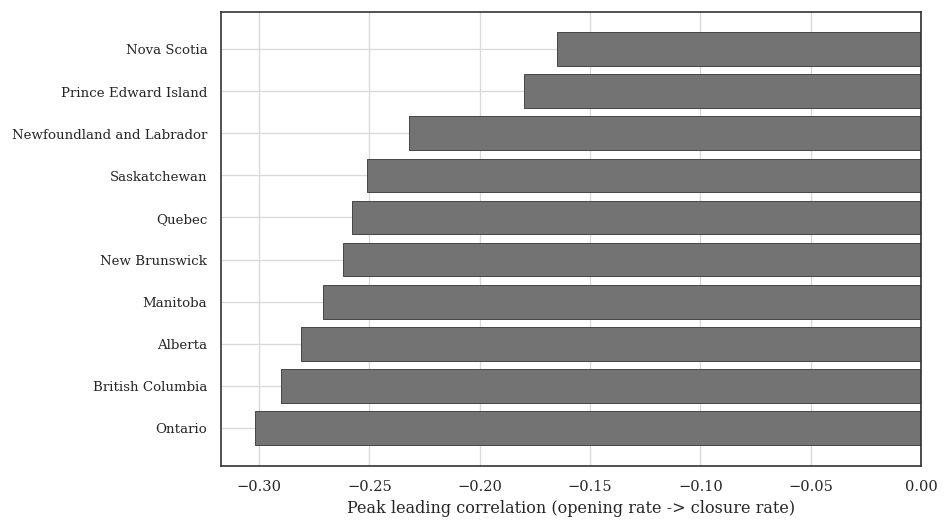

In [12]:
# Provincial robustness plot: distribution of peak leading correlations
fig, ax = plt.subplots(figsize=(8, 4.5))
order = rob_df.sort_values('peak_lead_corr')['province']
vals = rob_df.set_index('province').loc[order, 'peak_lead_corr']
ax.barh(range(len(vals)), vals.values, color=GREY_MID, edgecolor='0.2', linewidth=0.5)
ax.set_yticks(range(len(vals)))
ax.set_yticklabels(vals.index, fontsize=8)
ax.axvline(0, color='0.1', lw=0.8)
ax.set_xlabel('Peak leading correlation (opening rate -> closure rate)')
fig.tight_layout()
save_fig(fig, 'fig4_provincial_robustness')
plt.show()

## 7b. Threshold sensitivity of the screening decision

The scorecard's ADOPT threshold is a design parameter. To show the
screening is not an artifact of one arbitrary cutoff, we vary the ADOPT
composite threshold and record how the verdicts change. A discriminating
scorecard should separate candidates as the threshold rises.

saved: table6_threshold_sensitivity.csv


saved: fig5_threshold_sensitivity.png / fig5_threshold_sensitivity.pdf


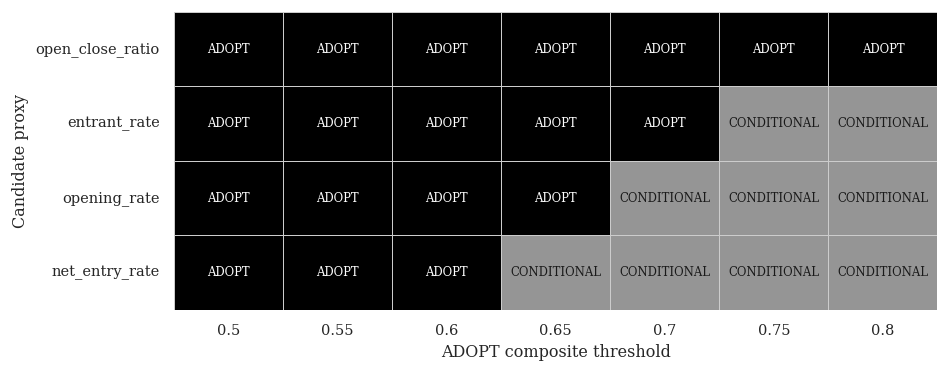

,adopt_threshold,n_adopt,n_candidates
0,0.50,4,4
1,0.55,4,4
2,0.60,4,4
3,0.65,3,4
4,0.70,2,4
5,0.75,1,4
6,0.80,1,4


In [13]:
# Threshold sensitivity: vary the ADOPT cutoff and record verdicts
cuts = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
comp = score_df.set_index('proxy')['composite_score']
rows = []
for cut in cuts:
    for p, c in comp.items():
        d = 'ADOPT' if c >= cut else ('CONDITIONAL' if c >= cut - 0.2 else 'REJECT')
        rows.append({'threshold': cut, 'proxy': p, 'decision': d})
sens = pd.DataFrame(rows)
summ = sens[sens.decision == 'ADOPT'].groupby('threshold').size().reindex(cuts, fill_value=0)
summ_df = pd.DataFrame({'adopt_threshold': cuts, 'n_adopt': summ.values, 'n_candidates': len(comp)})
summ_df.to_csv(TAB / 'table6_threshold_sensitivity.csv', index=False)
print('saved: table6_threshold_sensitivity.csv')

order = comp.sort_values(ascending=False).index.tolist()
mapping = {'ADOPT': 2, 'CONDITIONAL': 1, 'REJECT': 0}
mat = sens.pivot(index='proxy', columns='threshold', values='decision').loc[order]
matnum = mat.replace(mapping).astype(int)
fig, ax = plt.subplots(figsize=(8, 3.2))
sns.heatmap(matnum, annot=mat.values, fmt='', cmap='Greys', vmin=0, vmax=2,
            linewidths=0.5, linecolor='0.8', cbar=False, ax=ax)
# White text on dark ADOPT cells, dark text on light cells
for txt, code in zip(ax.texts, matnum.values.ravel()):
    txt.set_color('white' if code == 2 else '0.1')
    txt.set_fontsize(7)
ax.set_xlabel('ADOPT composite threshold')
ax.set_ylabel('Candidate proxy')
fig.tight_layout()
save_fig(fig, 'fig5_threshold_sensitivity')
plt.show()
summ_df

## 8. Summary

The analysis demonstrates the framework's opportunity-layer screening logic on real, open, aggregate data:
candidate weak signals are tested for leadingness (CCF), predictive value (Granger), and scored on the
framework's criteria into an ADOPT / CONDITIONAL / REJECT decision. All tables and figures are written to
`results/` for reproducibility. This is a proof-of-concept of the *screening procedure*, not a deployed model.